In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import yfinance as yf
from hmmlearn.hmm import GaussianHMM

plt.style.use('seaborn-v0_8-darkgrid')

In [20]:
TICKER = "SPY"
START  = "2016-01-01"
END    = "2026-04-14"

raw = yf.download(TICKER, start=START, end=END, auto_adjust=True, progress=False)
close = raw["Close"].squeeze().dropna()
log_returns = np.log(close).diff().dropna()

dates   = log_returns.index
returns = log_returns.values.reshape(-1, 1)   # hmmlearn expects (T, n_features)

print(f"Loaded {len(returns)} trading days: {dates[0].date()} → {dates[-1].date()}")

Loaded 2582 trading days: 2016-01-05 → 2026-04-13


In [21]:
N_STATES    = 3
N_ITER      = 200
RANDOM_SEED = 42

model = GaussianHMM(
    n_components=N_STATES,
    covariance_type="full",
    n_iter=N_ITER,
    random_state=RANDOM_SEED,
)
model.fit(returns)

print(f"Converged: {model.monitor_.converged}")
print(f"Log-likelihood: {model.score(returns):.2f}")

Converged: True
Log-likelihood: 8462.86


In [22]:
# Per-state mean return → sort ascending: lowest mean = bear
raw_means = model.means_.flatten()           # shape (N_STATES,)
order     = np.argsort(raw_means)            # ascending
LABELS    = {order[0]: "bear", order[1]: "neutral", order[2]: "bull"}
COLORS    = {"bear": "#ef4444", "neutral": "#f59e0b", "bull": "#22c55e"}

# Viterbi decode → most likely state sequence
hidden_states = model.predict(returns)       # shape (T,)
state_labels  = [LABELS[s] for s in hidden_states]

# Per-state annualized stats
for i, label in LABELS.items():
    seg = returns[hidden_states == i].flatten()
    print(f"State {i} ({label:7s}): μ_ann={np.mean(seg)*252:.4f}  σ_ann={np.std(seg)*np.sqrt(252):.4f}  n={len(seg)}")

State 2 (bear   ): μ_ann=-0.5231  σ_ann=0.3452  n=468
State 0 (neutral): μ_ann=0.2237  σ_ann=0.1191  n=1057
State 1 (bull   ): μ_ann=0.3407  σ_ann=0.1042  n=1057


In [23]:
print("Transition matrix:")
tm = model.transmat_
for i in range(N_STATES):
    row = "  ".join(f"→{LABELS[j]}:{tm[i,j]:.3f}" for j in range(N_STATES))
    print(f"  {LABELS[i]:7s}: {row}")

Transition matrix:
  neutral: →neutral:0.001  →bull:0.999  →bear:0.000
  bull   : →neutral:0.968  →bull:0.008  →bear:0.024
  bear   : →neutral:0.042  →bull:0.011  →bear:0.947


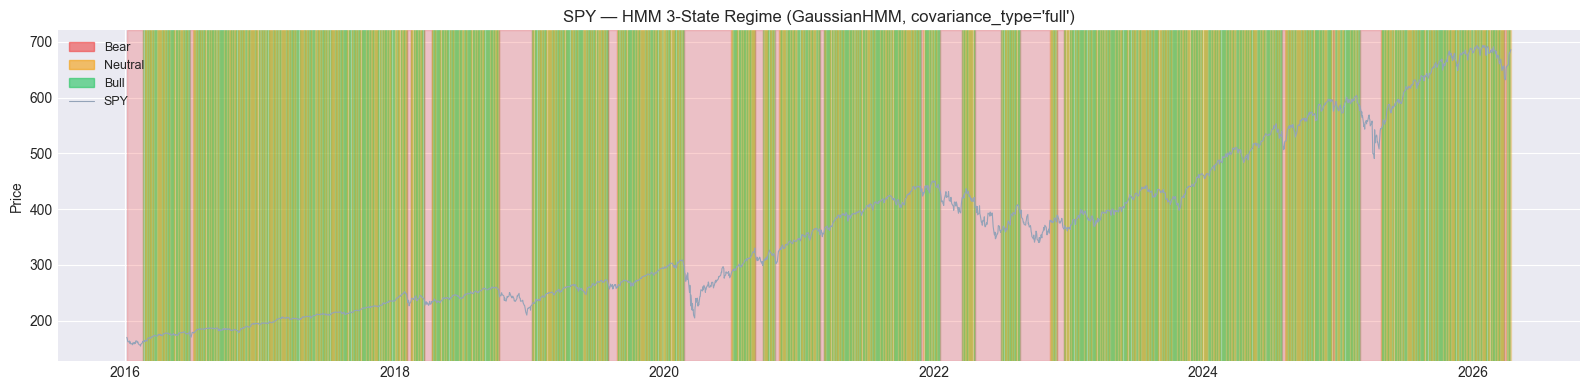

In [24]:
fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(dates, close.values[1:], color="#94a3b8", linewidth=0.8, label=TICKER)

# Shade regime bands
current_state = state_labels[0]
seg_start     = dates[0]
for i in range(1, len(state_labels)):
    if state_labels[i] != current_state or i == len(state_labels) - 1:
        ax.axvspan(seg_start, dates[i], alpha=0.25, color=COLORS[current_state])
        current_state = state_labels[i]
        seg_start     = dates[i]

patches = [mpatches.Patch(color=COLORS[l], alpha=0.6, label=l.capitalize())
           for l in ["bear", "neutral", "bull"]]
ax.legend(handles=patches + [ax.lines[0]], loc="upper left", fontsize=9)
ax.set_title(f"{TICKER} — HMM 3-State Regime (GaussianHMM, covariance_type='full')")
ax.set_ylabel("Price")
plt.tight_layout()
plt.show()

In [25]:
# Changepoints: days where state changes
cp_indices = [i for i in range(1, len(hidden_states)) if hidden_states[i] != hidden_states[i-1]]
boundaries = [0] + cp_indices + [len(hidden_states)]

rows = []
for sid in range(len(boundaries) - 1):
    s, e = boundaries[sid], boundaries[sid + 1]
    state = hidden_states[s]
    label = LABELS[state]
    stats_start = s + 1 if sid > 0 else s
    seg_rets = log_returns.values[stats_start:e]
    mean_ann = float(np.mean(seg_rets)) * 252       if len(seg_rets) > 1 else 0.0
    std_ann  = float(np.std(seg_rets, ddof=1)) * np.sqrt(252) if len(seg_rets) > 1 else 0.0
    rows.append({
        "segment": sid,
        "label":   label,
        "start":   str(dates[s].date()),
        "end":     str(dates[e-1].date()),
        "n_days":  e - s,
        "μ_ann":   round(mean_ann, 4),
        "σ_ann":   round(std_ann, 4),
    })

df_segs = pd.DataFrame(rows)
print(f"Total changepoints: {len(cp_indices)}")
print()
print(df_segs.to_string(index=False))

Total changepoints: 2132

 segment   label      start        end  n_days   μ_ann  σ_ann
       0    bear 2016-01-05 2016-02-17      30 -0.3472 0.2296
       1 neutral 2016-02-18 2016-02-18       1  0.0000 0.0000
       2    bull 2016-02-19 2016-02-19       1  0.0000 0.0000
       3 neutral 2016-02-22 2016-02-22       1  0.0000 0.0000
       4    bull 2016-02-23 2016-02-23       1  0.0000 0.0000
       5 neutral 2016-02-24 2016-02-24       1  0.0000 0.0000
       6    bull 2016-02-25 2016-02-25       1  0.0000 0.0000
       7 neutral 2016-02-26 2016-02-26       1  0.0000 0.0000
       8    bull 2016-02-29 2016-02-29       1  0.0000 0.0000
       9 neutral 2016-03-01 2016-03-01       1  0.0000 0.0000
      10    bull 2016-03-02 2016-03-02       1  0.0000 0.0000
      11 neutral 2016-03-03 2016-03-03       1  0.0000 0.0000
      12    bull 2016-03-04 2016-03-04       1  0.0000 0.0000
      13 neutral 2016-03-07 2016-03-07       1  0.0000 0.0000
      14    bull 2016-03-08 2016-03-08      

---
## Experiment: Adding Realized Volatility as a Second Feature

Replace single `log_return` input with 2D features `[log_return, rolling_vol]`.
Crash regimes are characterised by **high volatility**, not just negative returns.
With volatility as a feature the model can separate three regimes:

| State   | mu_return | mu_vol | Interpretation       |
|---------|-----------|--------|----------------------|
| bull    | high      | low    | Steady uptrend       |
| neutral | moderate  | medium | Choppy / sideways    |
| bear    | low / neg | high   | Crisis / bear market |

Comparing two rolling windows: 21-day (monthly, responsive) vs 63-day (quarterly, smooth)

In [26]:
def fit_hmm_2d(log_returns, roll_window: int, n_states: int = 3,
               n_iter: int = 300, seed: int = 42):
    roll_vol = log_returns.rolling(roll_window).std().bfill()
    features = np.column_stack([log_returns.values, roll_vol.values])

    m = GaussianHMM(n_components=n_states, covariance_type="full",
                    n_iter=n_iter, random_state=seed)
    m.fit(features)

    # Align by vol ascending: lowest vol = bull, highest vol = bear
    raw_vols = m.means_[:, 1]
    order    = np.argsort(raw_vols)
    labels   = {order[0]: "bull", order[1]: "neutral", order[2]: "bear"}
    colors   = {"bear": "#ef4444", "neutral": "#f59e0b", "bull": "#22c55e"}

    hidden = m.predict(features)
    return m, hidden, labels, colors, features


def print_state_stats(model, hidden, labels, log_returns):
    print(f"Converged: {model.monitor_.converged}")
    print()
    for state, label in sorted(labels.items(), key=lambda x: x[0]):
        seg = log_returns.values[hidden == state]
        mu  = np.mean(seg) * 252
        sig = np.std(seg) * np.sqrt(252)
        print(f"  state {state} ({label:7s}): μ_ann={mu:+.4f}  σ_ann={sig:.4f}  n={len(seg)}")
    print()
    print("Transition matrix:")
    tm = model.transmat_
    n  = len(labels)
    for i in range(n):
        row = "  ".join(f"→{labels[j]}:{tm[i,j]:.3f}" for j in range(n))
        print(f"  {labels[i]:7s}: {row}")


def plot_regime(ax, dates, close, hidden, labels, colors, title):
    """Plot price with regime colour bands. Works for any number of states."""
    state_seq = [labels[s] for s in hidden]
    ax.plot(dates, close.values[1:], color="#94a3b8", linewidth=0.7)

    # Draw colour bands
    cur, seg_s = state_seq[0], dates[0]
    for i in range(1, len(state_seq)):
        if state_seq[i] != cur:
            ax.axvspan(seg_s, dates[i], alpha=0.22, color=colors[cur])
            cur, seg_s = state_seq[i], dates[i]
    # Draw final segment
    ax.axvspan(seg_s, dates[-1], alpha=0.22, color=colors[cur])

    # Legend: derive from colors dict (preserves insertion order)
    patches = [mpatches.Patch(color=c, alpha=0.6, label=l)
               for l, c in colors.items() if l in set(state_seq)]
    ax.legend(handles=patches, loc="upper left", fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Price")

Model is not converging.  Current: 20130.162321863663 is not greater than 20130.439568164576. Delta is -0.277246300913248


=== 21-day rolling vol ===
Converged: True

  state 0 (neutral): μ_ann=-0.0484  σ_ann=0.2204  n=819
  state 1 (bull   ): μ_ann=+0.2368  σ_ann=0.0999  n=1693
  state 2 (bear   ): μ_ann=-0.1369  σ_ann=0.6143  n=70

Transition matrix:
  neutral: →neutral:0.981  →bull:0.016  →bear:0.003
  bull   : →neutral:0.008  →bull:0.992  →bear:0.000
  bear   : →neutral:0.046  →bull:0.000  →bear:0.954


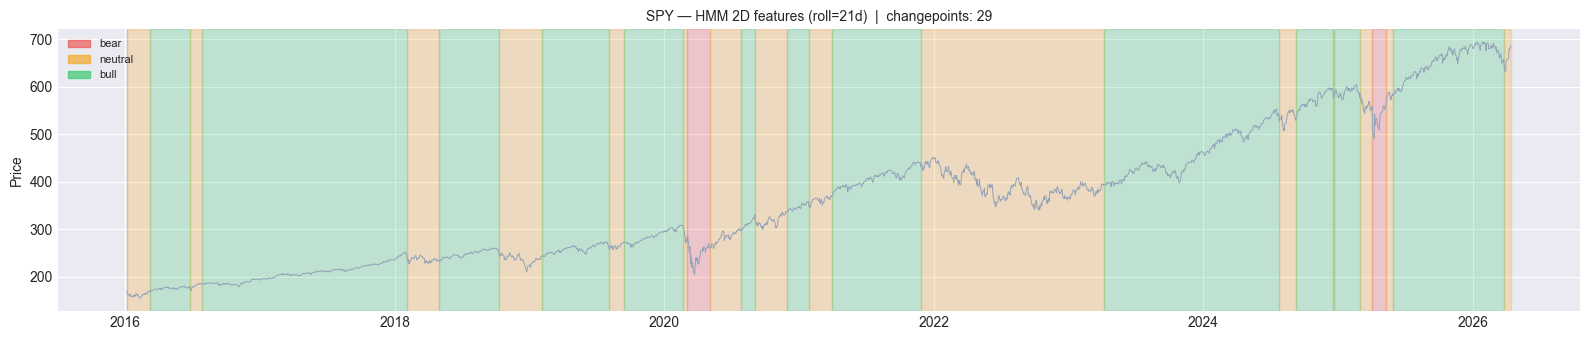

In [27]:
# -- 21-day window -----------------------------------------------------------
m21, h21, lab21, col21, feat21 = fit_hmm_2d(log_returns, roll_window=21)

print("=== 21-day rolling vol ===")
print_state_stats(m21, h21, lab21, log_returns)

fig, ax = plt.subplots(figsize=(16, 3.5))
plot_regime(ax, dates, close, h21, lab21, col21,
            f"{TICKER} — HMM 2D features (roll=21d)  |  "
            f"changepoints: {sum(h21[i]!=h21[i-1] for i in range(1,len(h21)))}")
plt.tight_layout()
plt.show()

=== 63-day rolling vol ===
Converged: True

  state 0 (neutral): μ_ann=-0.0121  σ_ann=0.2145  n=740
  state 1 (bull   ): μ_ann=+0.2083  σ_ann=0.1138  n=1763
  state 2 (bear   ): μ_ann=-0.0837  σ_ann=0.5765  n=79

Transition matrix:
  neutral: →neutral:0.984  →bull:0.013  →bear:0.003
  bull   : →neutral:0.005  →bull:0.995  →bear:0.000
  bear   : →neutral:0.025  →bull:0.000  →bear:0.975


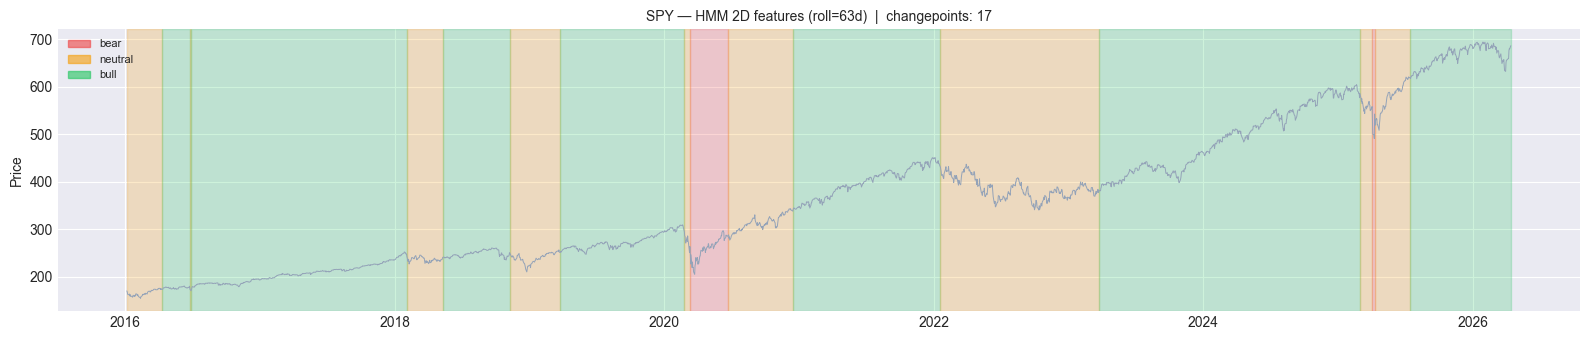

In [28]:
# -- 63-day window -----------------------------------------------------------
m63, h63, lab63, col63, feat63 = fit_hmm_2d(log_returns, roll_window=63)

print("=== 63-day rolling vol ===")
print_state_stats(m63, h63, lab63, log_returns)

fig, ax = plt.subplots(figsize=(16, 3.5))
plot_regime(ax, dates, close, h63, lab63, col63,
            f"{TICKER} — HMM 2D features (roll=63d)  |  "
            f"changepoints: {sum(h63[i]!=h63[i-1] for i in range(1,len(h63)))}")
plt.tight_layout()
plt.show()

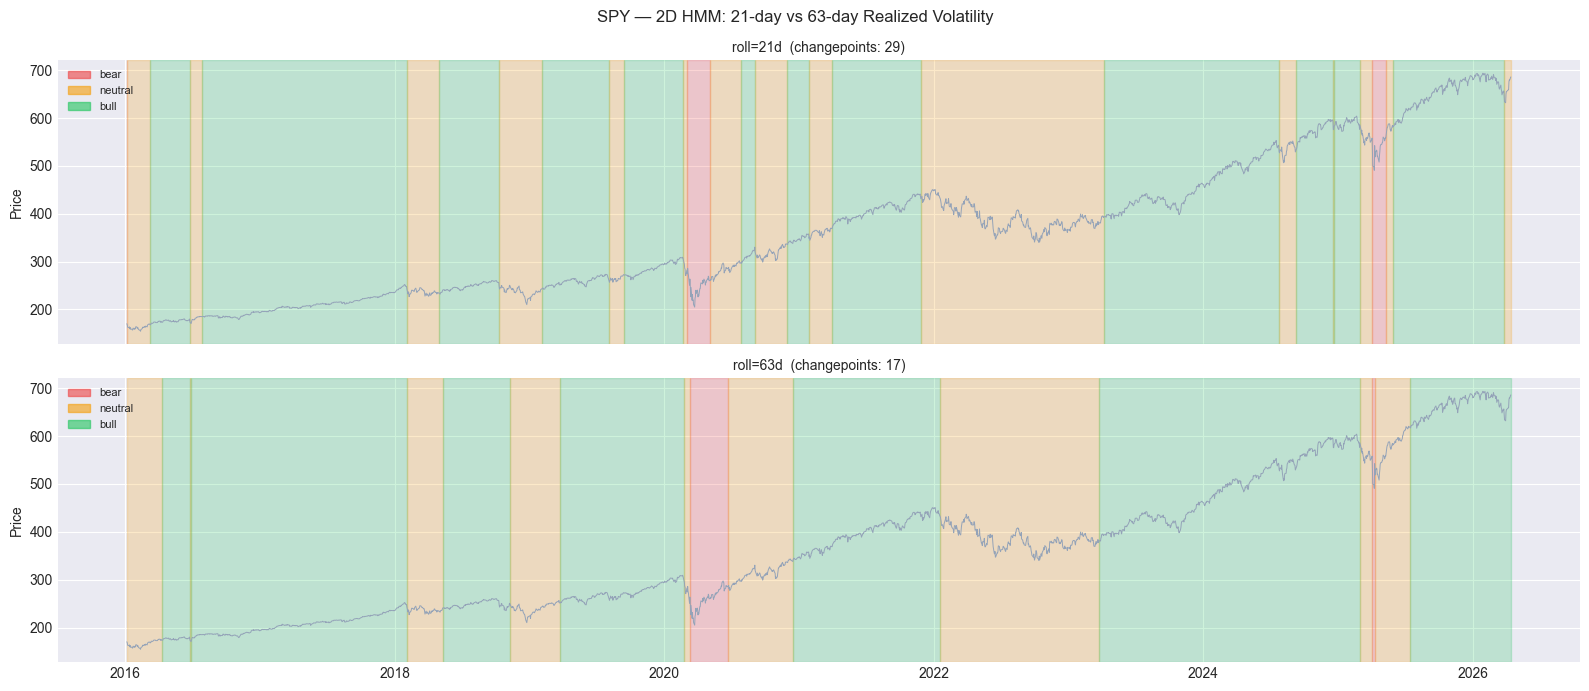

In [29]:
# -- Side-by-side comparison -------------------------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

cp21 = sum(h21[i] != h21[i-1] for i in range(1, len(h21)))
cp63 = sum(h63[i] != h63[i-1] for i in range(1, len(h63)))

plot_regime(ax1, dates, close, h21, lab21, col21,
            f"roll=21d  (changepoints: {cp21})")
plot_regime(ax2, dates, close, h63, lab63, col63,
            f"roll=63d  (changepoints: {cp63})")

fig.suptitle(f"{TICKER} — 2D HMM: 21-day vs 63-day Realized Volatility", fontsize=12)
plt.tight_layout()
plt.show()

---
## BIC Model Selection: N=2,3,4,5 States

BIC = **-2 × log-likelihood** (goodness of fit) + **k × log(T)** (complexity penalty)

The N with the lowest BIC offers the best trade-off between fit quality and model complexity.

In [30]:
# 21-day window features (better performance verified above)
roll_vol = log_returns.rolling(21).std().bfill()
features = np.column_stack([log_returns.values, roll_vol.values])

rows = []
for n in [2, 3, 4, 5]:
    m = GaussianHMM(n_components=n, covariance_type="full",
                    n_iter=300, random_state=42)
    m.fit(features)

    ll  = m.score(features)   # log-likelihood per sample
    k   = n**2 + 6*n          # n_params: transition matrix(n^2) + means(2n) + covariances(4n)
    bic = -2 * ll * len(features) + k * np.log(len(features))

    rows.append({"N": n, "BIC": round(bic, 1),
                 "log-likelihood": round(ll, 4),
                 "n_params (k)": k,
                 "converged": m.monitor_.converged})

df_bic = pd.DataFrame(rows)
best_n = df_bic.loc[df_bic["BIC"].idxmin(), "N"]

print(df_bic.to_string(index=False))
print(f"\n-> BIC optimal: N={best_n} states")

Model is not converging.  Current: 20130.162321863663 is not greater than 20130.439568164576. Delta is -0.277246300913248
Model is not converging.  Current: 20136.746669442018 is not greater than 20136.76106576035. Delta is -0.014396318332728697
Model is not converging.  Current: 19290.472381885553 is not greater than 19290.526894373208. Delta is -0.05451248765530181


 N          BIC  log-likelihood  n_params (k)  converged
 2 -100150012.5      19393.9075            16       True
 3 -103951217.7      20130.0213            27       True
 4 -103985819.6      20136.7416            40       True
 5  -99706385.5      19308.0592            55       True

-> BIC optimal: N=4 states


---
## N=4 State Visualisation

BIC optimal. States sorted by volatility ascending: lowest vol → highest vol.

In [31]:
# -- Fit N=4 -----------------------------------------------------------------
m4 = GaussianHMM(n_components=4, covariance_type="full",
                 n_iter=300, random_state=42)
m4.fit(features)   # features = [log_return, 21d_vol] defined in BIC cell above
h4 = m4.predict(features)

# Sort states by vol ascending: rank 0=lowest vol, rank 3=highest vol
order4  = np.argsort(m4.means_[:, 1])
LABELS4 = {order4[0]: "strong_bull",
           order4[1]: "weak_bull",
           order4[2]: "correction",
           order4[3]: "crisis"}
COLORS4 = {"strong_bull": "#16a34a", "weak_bull": "#86efac",
           "correction":  "#f59e0b", "crisis":    "#ef4444"}

# -- Per-state stats ---------------------------------------------------------
print("=== N=4 state stats ===\n")
print(f"{'label':>12}  {'mu_ann':>8}  {'sig_ann':>8}  {'n_days':>7}  {'pct':>6}")
print("-" * 48)
for state, label in sorted(LABELS4.items(), key=lambda x: m4.means_[x[0], 1]):
    seg = log_returns.values[h4 == state]
    mu  = np.mean(seg) * 252
    sig = np.std(seg)  * np.sqrt(252)
    n   = len(seg)
    print(f"{label:>12}  {mu:>+8.4f}  {sig:>8.4f}  {n:>7}  {n/len(h4):>6.1%}")

print()
print("Transition matrix:")
header = "             " + "  ".join(f"{LABELS4[order4[j]]:>12}" for j in range(4))
print(header)
for i in range(4):
    row = "  ".join(f"{m4.transmat_[i, order4[j]]:.3f}" for j in range(4))
    print(f"  {LABELS4[order4[i]]:>12}: {row}")

Model is not converging.  Current: 20136.746669442018 is not greater than 20136.76106576035. Delta is -0.014396318332728697


=== N=4 state stats ===

       label    mu_ann   sig_ann   n_days     pct
------------------------------------------------
 strong_bull   +0.2368    0.0999     1693   65.6%
   weak_bull      +nan       nan        0    0.0%
  correction   -0.0478    0.2202      820   31.8%
      crisis   -0.1450    0.6187       69    2.7%

Transition matrix:
              strong_bull     weak_bull    correction        crisis
   strong_bull: 1.000  0.000  0.000  0.000
     weak_bull: 0.016  0.000  0.982  0.003
    correction: 0.992  0.000  0.008  0.000
        crisis: 0.000  0.000  0.031  0.969


/opt/anaconda3/envs/bayes/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/bayes/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/envs/bayes/lib/python3.10/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/bayes/lib/python3.10/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/bayes/lib/python3.10/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [32]:
# -- Debug: check which states actually appear in Viterbi path ---------------
unique_states, counts = np.unique(h4, return_counts=True)
print("Raw state counts from Viterbi decode:")
for s, c in zip(unique_states, counts):
    print(f"  state {s}: {c} days -> label = '{LABELS4[s]}'")

print()
print("States present in decoded sequence:", set(LABELS4[s] for s in h4))
print("States in LABELS4:", set(LABELS4.values()))
print("Missing:", set(LABELS4.values()) - set(LABELS4[s] for s in h4))

Raw state counts from Viterbi decode:
  state 1: 820 days -> label = 'correction'
  state 2: 1693 days -> label = 'strong_bull'
  state 3: 69 days -> label = 'crisis'

States present in decoded sequence: {'strong_bull', 'correction', 'crisis'}
States in LABELS4: {'weak_bull', 'strong_bull', 'correction', 'crisis'}
Missing: {'weak_bull'}


---
## Experiment: 3D Features — Adding Medium-term Momentum

Problem with 2D model: the `bear` state only triggers on extreme volatility spikes (2020, 2025).
Sustained declines with moderate volatility (e.g. 2022) are labelled `neutral`.

Fix: add a **63-day cumulative return** as a third feature so the model can detect price direction.

| Feature        | What it captures                        |
|----------------|-----------------------------------------|
| log_return     | Daily noise level                       |
| rolling_vol_21 | Short-term volatility                   |
| momentum_63    | Medium-term trend direction (~1 quarter)|

State alignment: sort by `momentum_63` mean ascending → bear = most negative trend, bull = most positive.

In [39]:
# -- Build 3D features -------------------------------------------------------
roll_vol_21  = log_returns.rolling(21).std().bfill()
momentum_63  = log_returns.rolling(14).sum().bfill()   # 63-day cumulative return

features_3d = np.column_stack([
    log_returns.values,
    roll_vol_21.values,
    momentum_63.values,
])

# -- Fit HMM -----------------------------------------------------------------
m3d = GaussianHMM(n_components=3, covariance_type="full",
                  n_iter=300, random_state=42)
m3d.fit(features_3d)
h3d = m3d.predict(features_3d)

# -- State alignment: sort by momentum_63 mean (col 2) ascending
# bear = most negative momentum, bull = most positive
order3d = np.argsort(m3d.means_[:, 2])
LABELS3D = {order3d[0]: "bear", order3d[1]: "neutral", order3d[2]: "bull"}
COLORS3D = {"bear": "#ef4444", "neutral": "#f59e0b", "bull": "#22c55e"}

# -- Per-state stats ---------------------------------------------------------
print(f"Converged: {m3d.monitor_.converged}\n")
print(f"{'label':>8}  {'mu_ann':>8}  {'sig_ann':>8}  {'mom_63':>8}  {'n_days':>7}  {'pct':>6}")
print("-" * 56)
for state, label in sorted(LABELS3D.items(), key=lambda x: m3d.means_[x[0], 2]):
    seg   = log_returns.values[h3d == state]
    mu    = np.mean(seg) * 252
    sig   = np.std(seg)  * np.sqrt(252)
    mom   = m3d.means_[state, 2]          # per-state mean of momentum_63
    n     = len(seg)
    print(f"{label:>8}  {mu:>+8.4f}  {sig:>8.4f}  {mom:>+8.4f}  {n:>7}  {n/len(h3d):>6.1%}")

print()
print("Transition matrix:")
for i in range(3):
    row = "  ".join(f"-> {LABELS3D[order3d[j]]}: {m3d.transmat_[i, order3d[j]]:.3f}"
                    for j in range(3))
    print(f"  {LABELS3D[order3d[i]]:>8}: {row}")

Converged: True

   label    mu_ann   sig_ann    mom_63   n_days     pct
--------------------------------------------------------
    bear   -0.7032    0.5583   -0.0454      101    3.9%
 neutral   -0.0228    0.2021   -0.0041      965   37.4%
    bull   +0.2934    0.0885   +0.0177     1516   58.7%

Transition matrix:
      bear: -> bear: 0.006  -> neutral: 0.963  -> bull: 0.030
   neutral: -> bear: 0.942  -> neutral: 0.058  -> bull: 0.000
      bull: -> bear: 0.000  -> neutral: 0.019  -> bull: 0.981


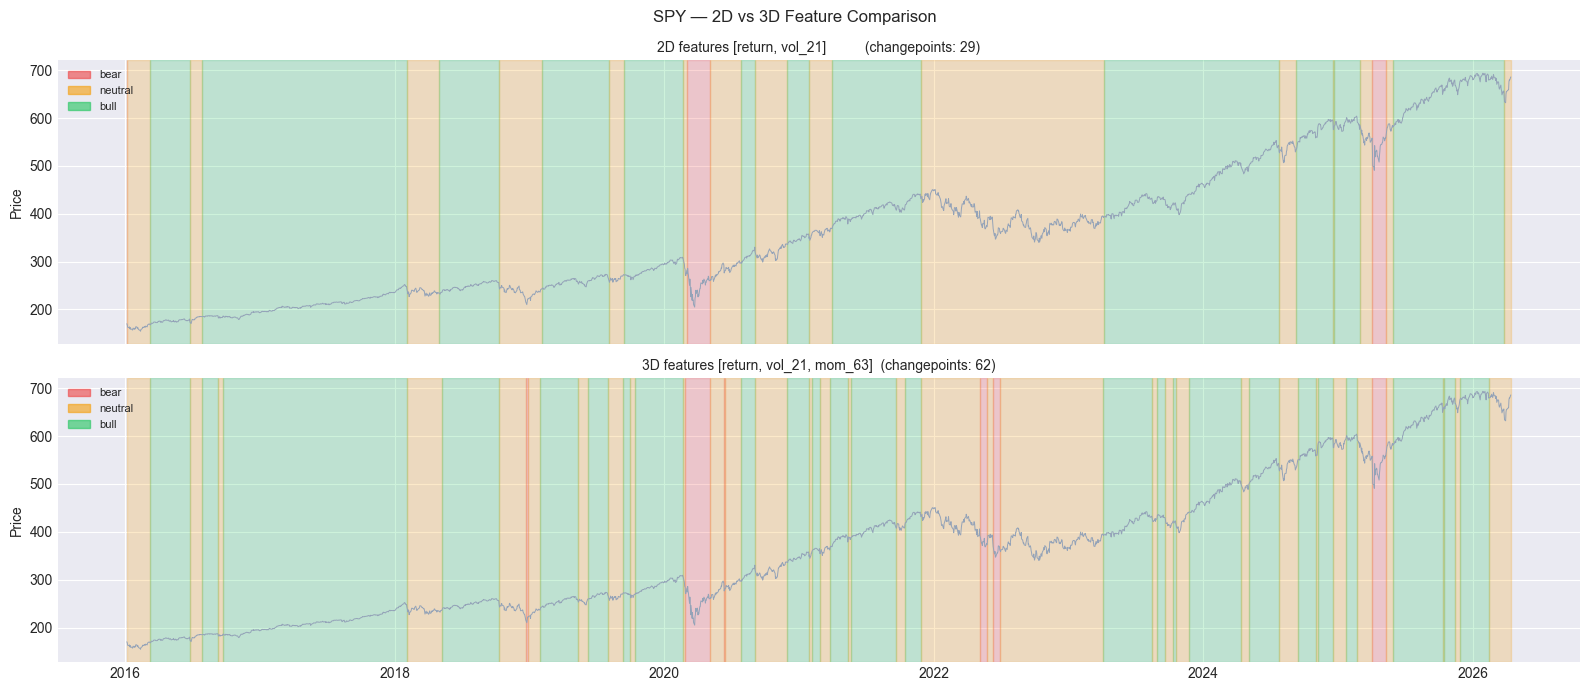

In [40]:
# -- Compare 2D vs 3D side by side -------------------------------------------
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

cp2d = sum(h21[i] != h21[i-1] for i in range(1, len(h21)))
cp3d = sum(h3d[i] != h3d[i-1] for i in range(1, len(h3d)))

plot_regime(ax_top, dates, close, h21, lab21, col21,
            f"2D features [return, vol_21]          (changepoints: {cp2d})")
plot_regime(ax_bot, dates, close, h3d, LABELS3D, COLORS3D,
            f"3D features [return, vol_21, mom_63]  (changepoints: {cp3d})")

fig.suptitle(f"{TICKER} — 2D vs 3D Feature Comparison", fontsize=12)
plt.tight_layout()
plt.show()

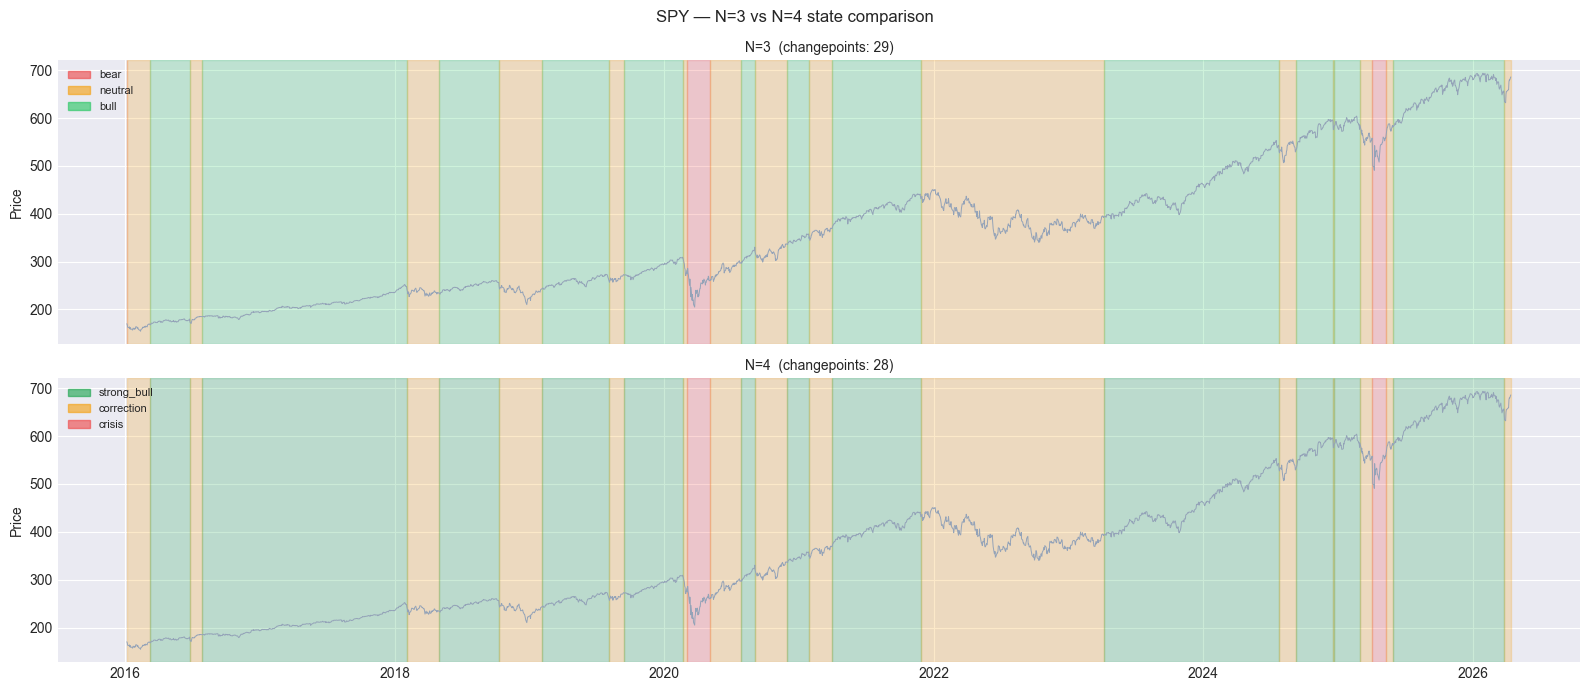

In [41]:
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

cp21 = sum(h21[i] != h21[i-1] for i in range(1, len(h21)))
cp4  = sum(h4[i]  != h4[i-1]  for i in range(1, len(h4)))

plot_regime(ax_top, dates, close, h21, lab21, col21,
            f"N=3  (changepoints: {cp21})")
plot_regime(ax_bot, dates, close, h4, LABELS4, COLORS4,
            f"N=4  (changepoints: {cp4})")

fig.suptitle(f"{TICKER} — N=3 vs N=4 state comparison", fontsize=12)
plt.tight_layout()
plt.show()